# MNIST
## 01. Dataset Exploration

In [1]:
from IPython.display import display
from infdsa_mnist import dsex_calculations, dsex_tables, dataset_loader

Before we can explore the dataset and train a model, we first have to put the data under the loop and answer several questions about it. The main question we will address in this notebook is:
**What really is a dataset?**

To answer this question, we will first explore the dataset and determine its characteristics, such as the number of images, the distribution of digits, and the shape and datatype of the images. This will help us understand the structure of the dataset and will help us to answer the posed question.

Before we can explore the dataset, we need to load it. To get familiar with machine learning, we will use the MNIST dataset, and we will go through its characteristics to gain familiarity with the dataset.

To load the MNIST dataset, we will use the `load_mnist` function in the `dsex_load` module. This function will load the MNIST dataset and return the training and testing data.

In [2]:
(train_data, test_data) = dataset_loader.load_mnist()

x_train, y_train = train_data
x_test, y_test = test_data

We must first understand the structure of the dataset to determine its characteristics and potential challenges. To ensure we have a clear understanding of the dataset, we will need to answer several questions about it. The answers to these questions will be gathered using the `dsex_calculations` module, and will be presented in a clear and organized manner using the `dsex_tables` module. The following are the questions we will address in this notebook to answer the main question posed in the introduction:

1. How many images are in the dataset in total?
2. How many examples are there for each digit (0–9) in the dataset?
3. Is the dataset balanced, meaning that each digit has approximately the same number of examples?
    - Which digit has the most examples, and which digit has the fewest examples in the dataset?
4. How large is a single image in terms of shape and datatype?

To start off, we must confirm the dataset has been loaded correctly. We can do this by displaying a single image from the dataset. We will also rotate it 90 degrees to confirm that the images are being displayed consistently and that the pixel values are being interpreted correctly.

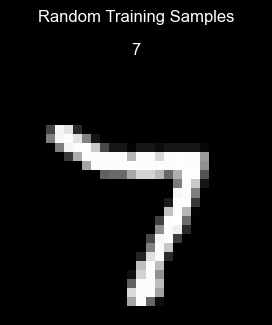

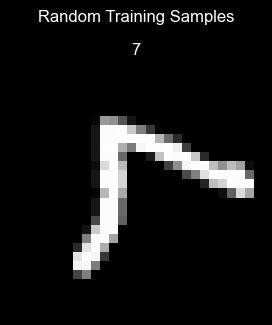

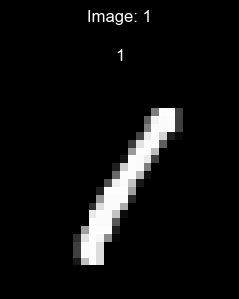

In [3]:
dsex_calculations.show_image(x_train, y_train, amount=1, seed=42)
dsex_calculations.show_image(x_train, y_train, amount=1, seed=42, rotate=True)

## How many images are in the dataset in total?
We can use the `image_count` function to determine the total number of images in the dataset. It takes the training and testing data as input and returns a breakdown of the total images in the training set, the testing set, and the total number of images in the dataset.

In [4]:
train_images, test_images, total_images = dsex_calculations.image_count(x_train, x_test)

image_count_df = dsex_tables.create_image_count_df(train_images, test_images, total_images)
display(image_count_df)

Set,Images
Training,60000
Testing,10000
Total,70000


The MNIST dataset, according to the `image_count` function, contains 70,000 images in total, with 60,000 images in the training set and 10,000 images in the testing set.

## How many examples are there for each digit (0–9) in the dataset?
To determine the number of examples for each digit, we can use the `digit_distribution` function. This function takes the training and testing labels as input and returns a dictionary with the count of examples for each digit (0–9) in the dataset.

In [5]:
distribution = dsex_calculations.digit_distribution(y_train, y_test)

distribution_df = dsex_tables.create_digit_distribution(distribution)
display(distribution_df)

Digit,Count,Percentage
0,6903,9.86%
1,7877,11.25%
2,6990,9.99%
3,7141,10.20%
4,6824,9.75%
5,6313,9.02%
6,6876,9.82%
7,7293,10.42%
8,6825,9.75%
9,6958,9.94%


## Is the dataset balanced?
To determine if the dataset is balanced, we will use the `is_balanced` function. It will indicate whether the dataset is balanced based on the distribution of digits and a threshold (default: 1.5, but could be adjusted here). A dataset is considered balanced if the count of each digit does not deviate from the mean count by more than the specified threshold.

In [6]:
threshold = 1.5

balance = dsex_calculations.is_balanced(distribution, threshold)
display(balance)

'The dataset is balanced.'

The dataset is balanced on its default threshold of 1.5, and could be considered balanced even on a stricter threshold of 1.25, as the counts for each digit do not deviate from the mean count by more than these thresholds.

In [7]:
most_least_df = dsex_tables.create_most_least_df(distribution)
display(most_least_df)

Category,Digit,Count
Most Common,1,7877
Least Common,5,6313


The dataset is relatively balanced, as the counts for each digit are close to each other. The most common digit is '1' with 7,877 examples, while the least common digit is '5' with 6,313 examples.



## How large is a single image in terms of shape and datatype?
To determine the shape and datatype of a single image in the dataset, we can use the `image_shape_and_dtype` function. This function takes the training data as input and returns the shape and datatype of a single image.

In [8]:
shape, dtype = dsex_calculations.image_shape_and_dtype(x_train)

image_info_df = dsex_tables.create_image_info_df(shape, dtype)
display(image_info_df)

Attribute,Value
Shape,28x28 px
Datatype,8-bit unsigned integer


Important to note here is that the datatype of the images is an 8-bit unsigned integer. What this means in reality is this:
- Each image is represented as a 28x28 array of pixel values.
- Each pixel value is an integer between 0 and 255, where 0 represents black and 255 represents white. The values in between represent different shades of gray.
- The shape of each image is (28, 28), which means that each image has 28 rows and 28 columns of pixel values.
- A pixel value cannot be negative or exceed 255, which is important to keep in mind when performing operations on the images. Consistency in pixel values should be maintained throughout the dataset to ensure the data does not lead to unexpected results when trying to alter it for performance or augmentation purposes.

We should also discover how much memory a single image takes up, and how much memory the entire dataset takes up. This is important to understand when working with the dataset, as it can affect the performance of our machine learning models and the resources required to train them. We can use the `memory_usage` function to determine the memory usage of a single image and the entire dataset.

In [9]:
single_image_memory, total_memory = dsex_calculations.memory_usage(x_train, x_test)

memory_usage_df = dsex_tables.create_memory_usage_df(single_image_memory, total_memory)
display(memory_usage_df)

Attribute,Value
Single Image Memory Usage,784 B
Total Memory Usage,52.34 MB


To summarize the dataset exploration, we can compile all the information we have gathered into a single summary table. This table will include all the relevant information about the dataset collected from the previous steps in one place, making it easier to understand the characteristics of the dataset at a glance.

In [10]:
shape, dtype, train_count, test_count, total_count, distribution, balance = dsex_calculations.explore_dataset(x_train, y_train, x_test, y_test, threshold)

dataset_summary_df = dsex_tables.create_dataset_summary_df(shape, dtype, train_count, test_count, total_count, balance, threshold)
display(dataset_summary_df)

Attribute,Value
Shape of a Single Image,28x28 px
Datatype of a Single Image,8-bit unsigned integer
Number of Training Images,60000
Number of Testing Images,10000
Total Number of Images,70000
Balance Threshold,1.50
Balanced Status,The dataset is balanced.


In [11]:
display(distribution_df)

Digit,Count,Percentage
0,6903,9.86%
1,7877,11.25%
2,6990,9.99%
3,7141,10.20%
4,6824,9.75%
5,6313,9.02%
6,6876,9.82%
7,7293,10.42%
8,6825,9.75%
9,6958,9.94%


## Conclusion

After exploring the dataset structure, we can now answer the question posed in the introduction:
**What really is a dataset?**

A dataset is not just a collection of images or files. In the context of machine learning, a dataset is a structured collection of samples. Each sample consists of input data, and in cases of supervised learning, it also includes a corresponding target label.

In the case of the MNIST dataset, each sample consists of:

- **Input data**: A 28x28 grayscale image of a handwritten digit.
- **Target labels**: An integer from 0 to 9 representing the digit depicted in the image.

From our exploration, we can describe the dataset as follows:
- It consists of 70,000 images in total.
- 60,000 images are used for training and 10,000 for testing.
- Each image is a fixed-size 28x28 grayscale image of a handwritten digit.
- The labels are integers representing one of the 10 classes (0–9).
- The dataset is roughly balanced, meaning that each digit appears with a similar frequency.

Because the dataset has a clear structure and is balanced, MNIST is a well-suited dataset for machine learning tasks. The main challenge that we will face is classifying handwritten digits, mostly due to the inherent variability in handwriting, alignment, shape, and other visual characteristics.
The next step, therefore, is to analyze the dataset visually. This will help us gain a better understanding of the dataset's characteristics and identify potential challenges that may arise when trying to classify handwritten digits. This will be the focus of the next notebook, `02_visual_analysis`.